Title: tasmax_dist_comp.ipynb

Purpose: Compare the distribution of tasmax in current and future climate

Author: Onno Nennecke on 02.06.2025 Modified: 12.05.2026

Input data: 

- tasmax Data from CMIP
    - These files lie here: /climca/people/onennecke/not_debiased_data/
    - These files lie here: /climca/people/onennecke/not_debiased_data_future/
- Used Runs File: CMIP6_runs_future.csv and CESM2_LE_runs.csv
    - These files lie here: /home/onennecke/CMIP_models/

Output data:

- Some plots to compare

### Load libraries and functions

In [3]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance
import os

### Define var name

In [4]:
variable_name = 'tasmax'

### Read data

In [5]:
# Read the dataframe from the csv file
used_runs_fut = pd.read_csv('/home/onennecke/CMIP_models/CMIP6_runs_future.csv')
used_runs_CESM_LE = pd.read_csv('/home/onennecke/CMIP_models/CESM2_LE_runs.csv')


used_runs = pd.concat([used_runs_fut, used_runs_CESM_LE], ignore_index=True)

# Change the ref column to 1 for the first instance of each model
# used_runs['Ref'] = used_runs.groupby(['ESM', 'Institution']).cumcount().apply(lambda x: 1 if x == 0 else 0)

ESMs = used_runs['ESM'].unique()

In [6]:
base_path_fut = '/climca/people/onennecke/not_debiased_data_future/'
base_path_cur = '/climca/people/onennecke/not_debiased_data/'

# Build a list of file names from the used_runs dataframe
file_names = []
for index, row in used_runs.iterrows():
    esm = row['ESM']
    # institution = row['Institution']
    run = row['run']
    
    # Construct the file name based on the ESM, institution, and run
    file_name_pattern = f'{esm}_{run}_{variable_name}.nc'
    
    # Append the file name pattern to the list
    file_names.append(file_name_pattern)
# file_names


In [7]:
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
mask_offshore = xr.where(np.isfinite(grid_offshore), 1, 0)
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
mask_onshore = xr.where(np.isfinite(grid_onshore), 1, 0)
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto.nc')
# grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid_solar = grid_solar['solar_cap']
mask_solar = xr.where(np.isfinite(grid_solar), 1, 0)
population = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')
population = population['population']
mask_population = xr.where(np.isfinite(population), 1, 0)
# Overall mask
overall_mask = mask_offshore + mask_onshore + mask_solar + mask_population
overall_mask = xr.where(overall_mask > 0, 1, 0)

In [8]:
ds_list = []
counter = 1
for file_name in file_names:
    file_path = os.path.join(base_path_cur, file_name)
    print(f'{counter}/{len(file_names)}: Processing file: {file_path}')
    if os.path.exists(file_path):
        ds = xr.open_dataset(file_path)
        esm_run = ds.ESM_run.values
        # Select only 6 winter months (October to March)
        ds = ds.sel(time=ds['time.month'].isin([10, 11, 12, 1, 2, 3]))
        # Mask the data with the overall mask
        ds = ds.where(overall_mask == 1)        
        # Calculate the spatial mean over the dimension
        mean_ds = ds.mean(dim=['lat', 'lon'], keep_attrs=True)
        
        ts_output = mean_ds.expand_dims(ESM_run=[esm_run]).assign_coords(ESM_run=[esm_run])
        ds_list.append(ts_output)
    else:
        print(f'File not found: {file_path}')
    counter += 1
esm_ds_cur = xr.concat(ds_list, dim="ESM_run")

ds_list = []
counter = 1
for file_name in file_names:
    file_path = os.path.join(base_path_fut, file_name)
    print(f'{counter}/{len(file_names)}: Processing file: {file_path}')
    if os.path.exists(file_path):
        ds = xr.open_dataset(file_path)
        esm_run = ds.ESM_run.values
        # Select only 6 winter months (October to March)
        ds = ds.sel(time=ds['time.month'].isin([10, 11, 12, 1, 2, 3]))
        # Mask the data with the overall mask
        ds = ds.where(overall_mask == 1)        
        # Calculate the spatial mean over the dimension
        mean_ds = ds.mean(dim=['lat', 'lon'], keep_attrs=True)
        
        ts_output = mean_ds.expand_dims(ESM_run=[esm_run]).assign_coords(ESM_run=[esm_run])
        ds_list.append(ts_output)
    else:
        print(f'File not found: {file_path}')
    counter += 1
esm_ds_fut = xr.concat(ds_list, dim="ESM_run")

1/192: Processing file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r4i1p1f1_tasmax.nc
2/192: Processing file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r5i1p1f1_tasmax.nc
3/192: Processing file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r1i1p1f1_tasmax.nc
4/192: Processing file: /climca/people/onennecke/not_debiased_data/BCC-CSM2-MR_r1i1p1f1_tasmax.nc
5/192: Processing file: /climca/people/onennecke/not_debiased_data/CESM2_r4i1p1f1_tasmax.nc
6/192: Processing file: /climca/people/onennecke/not_debiased_data/CESM2_r10i1p1f1_tasmax.nc
7/192: Processing file: /climca/people/onennecke/not_debiased_data/CESM2_r11i1p1f1_tasmax.nc
8/192: Processing file: /climca/people/onennecke/not_debiased_data/EC-Earth3_r149i1p1f1_tasmax.nc
9/192: Processing file: /climca/people/onennecke/not_debiased_data/EC-Earth3_r4i1p1f1_tasmax.nc
10/192: Processing file: /climca/people/onennecke/not_debiased_data/EC-Earth3_r148i1p1f1_tasmax.nc
11/192: Processing file: /climca/people/

In [9]:
esm_ds_cur

<xarray.Dataset> Size: 1MB
Dimensions:   (ESM_run: 192, time: 1820)
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'CESM2_LE'
    run       (ESM_run) <U12 9kB 'r4i1p1f1' 'r5i1p1f1' ... 'LE2-1301_020'
    country   float64 8B 9.0
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'CESM2_LE_LE2-130...
Data variables:
    tasmax    (ESM_run, time) float32 1MB 278.1 279.4 278.4 ... 279.0 281.7
Attributes:
    regrid_method:  bilinear

In [10]:
192*1820

349440

In [11]:
esm_ds_fut

<xarray.Dataset> Size: 4MB
Dimensions:   (ESM_run: 192, time: 4550)
Coordinates:
  * time      (time) datetime64[ns] 36kB 2030-01-01 2030-01-02 ... 2054-12-31
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'CESM2_LE_LE2-130...
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'CESM2_LE'
    run       (ESM_run) <U12 9kB 'r4i1p1f1' 'r5i1p1f1' ... 'LE2-1301_020'
    country   float64 8B 9.0
Data variables:
    tasmax    (ESM_run, time) float32 3MB nan nan nan nan ... nan nan nan nan
Attributes:
    regrid_method:  bilinear

In [12]:
np.unique(esm_ds_cur.ESM.values)

array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'CESM2_LE', 'EC-Earth3',
       'GFDL-ESM4', 'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0',
       'TaiESM1', 'UKESM1-0-LL'], dtype='<U13')

In [13]:
esm_data_cur_dict = {}
esm_data_fut_dict = {}

esm_data_cur_dict['All'] = esm_ds_cur[variable_name].values.ravel()
esm_data_fut = esm_ds_fut[variable_name].values.ravel()
esm_data_fut = esm_data_fut[~np.isnan(esm_data_fut)]
esm_data_fut_dict['All'] = esm_data_fut

for esm in np.unique(esm_ds_cur.ESM.values):
    esm_data_cur = esm_ds_cur.where(esm_ds_cur.ESM == esm)[variable_name].values.ravel()
    esm_data_cur = esm_data_cur[~np.isnan(esm_data_cur)]
    esm_data_cur_dict[esm] = esm_data_cur
    esm_data_fut = esm_ds_fut.where(esm_ds_fut.ESM == esm)[variable_name].values.ravel()
    esm_data_fut = esm_data_fut[~np.isnan(esm_data_fut)]
    esm_data_fut_dict[esm] = esm_data_fut
    # break


In [14]:
esm_data_cur_dict.keys()

for key in esm_data_cur_dict.keys():
    print(f'{key}: {len(esm_data_cur_dict[key])} values')
    print(f'{key}: {len(esm_data_cur_dict[key]) / 1820} values')

All: 349440 values
All: 192.0 values
ACCESS-CM2: 5460 values
ACCESS-CM2: 3.0 values
BCC-CSM2-MR: 1820 values
BCC-CSM2-MR: 1.0 values
CESM2: 5460 values
CESM2: 3.0 values
CESM2_LE: 182000 values
CESM2_LE: 100.0 values
EC-Earth3: 98280 values
EC-Earth3: 54.0 values
GFDL-ESM4: 1820 values
GFDL-ESM4: 1.0 values
KACE-1-0-G: 5460 values
KACE-1-0-G: 3.0 values
MPI-ESM1-2-HR: 18200 values
MPI-ESM1-2-HR: 10.0 values
MRI-ESM2-0: 9100 values
MRI-ESM2-0: 5.0 values
TaiESM1: 1820 values
TaiESM1: 1.0 values
UKESM1-0-LL: 20020 values
UKESM1-0-LL: 11.0 values


/tmp/ipykernel_3462047/1858461589.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_3462047/1858461589.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_3462047/1858461589.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_3462047/1858461589.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_3462047/1858461589.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() 

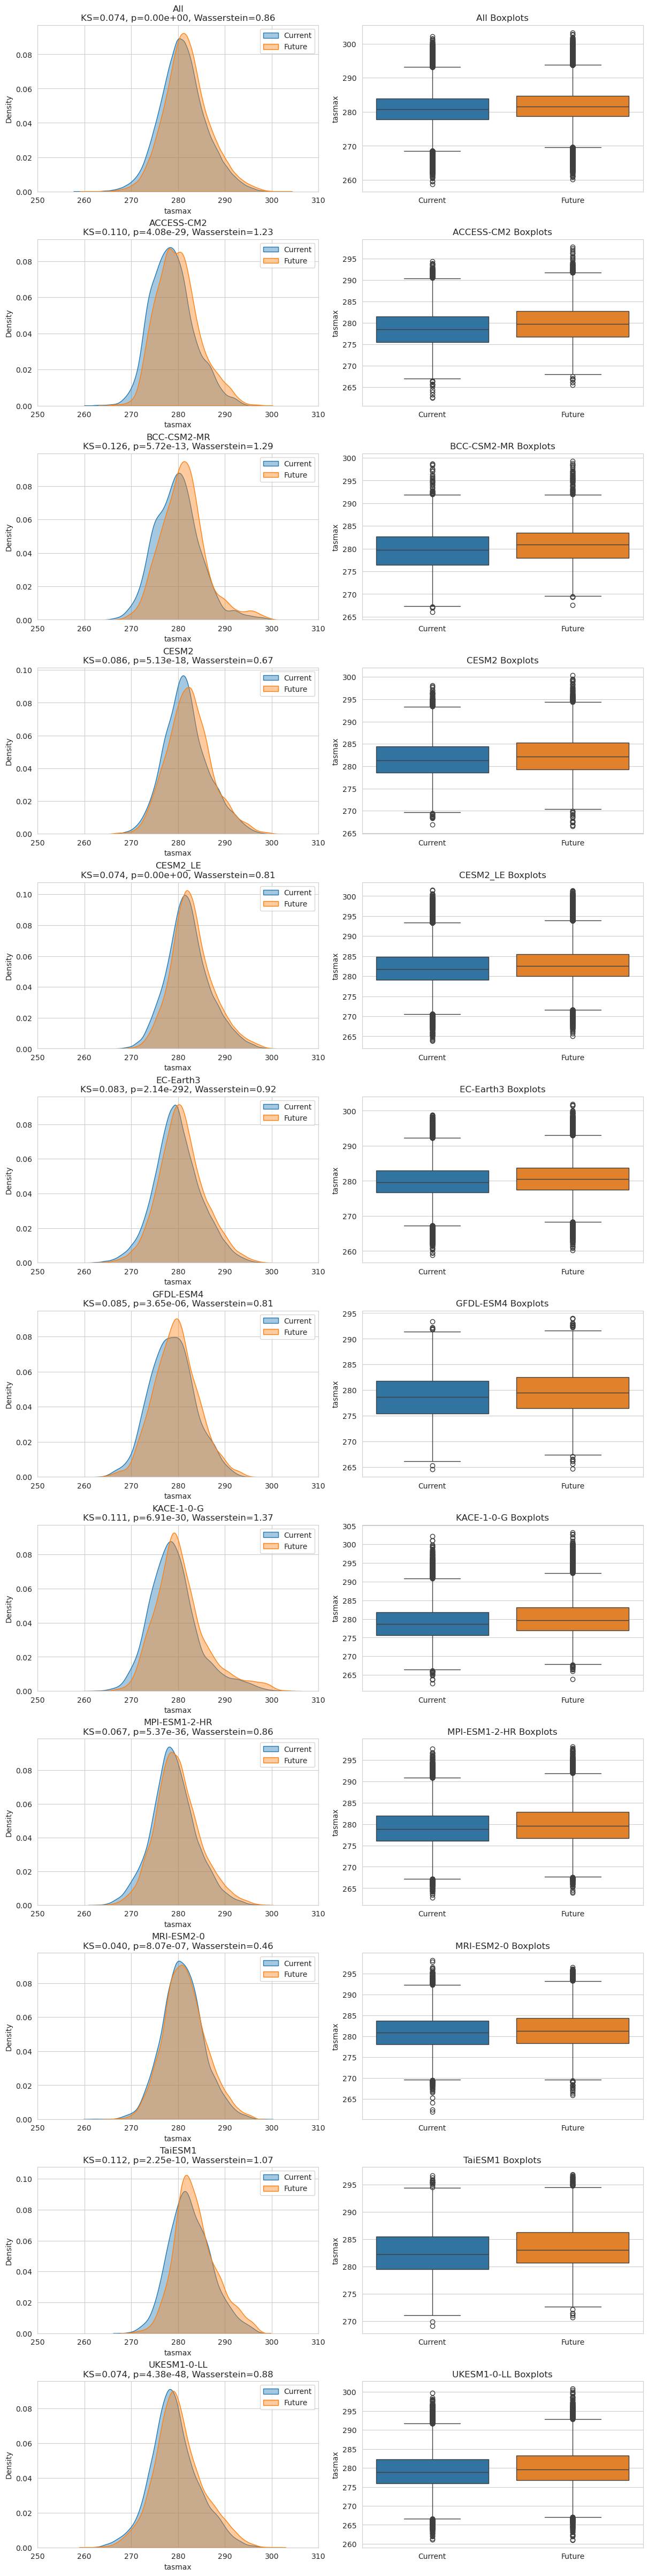

In [20]:

sns.set_style("whitegrid")

all_keys = list(esm_data_cur_dict.keys())

n = len(all_keys)

fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(12, 4 * n),
    constrained_layout=True
)

# handle case n=1
if n == 1:
    axes = np.array([axes])

for i, esm in enumerate(all_keys):

    cur = esm_data_cur_dict[esm]
    fut = esm_data_fut_dict[esm]

    # -------------------------
    # KDE plot
    # -------------------------
    ax = axes[i, 0]

    sns.kdeplot(cur, ax=ax, label='Current', fill=True, alpha=0.4)
    sns.kdeplot(fut, ax=ax, label='Future', fill=True, alpha=0.4)
    ax.set_xlim(250, 310)
    # metrics
    ks_stat, ks_p = ks_2samp(cur, fut)
    wass = wasserstein_distance(cur, fut)

    ax.set_title(
        f"{esm}\nKS={ks_stat:.3f}, p={ks_p:.2e}, Wasserstein={wass:.2f}"
    )
    ax.set_xlabel(variable_name)
    ax.legend()

    # -------------------------
    # Boxplot
    # -------------------------
    ax2 = axes[i, 1]

    sns.boxplot(
        data=[cur, fut],
        ax=ax2
    )

    ax2.set_xticklabels(['Current', 'Future'])
    ax2.set_title(f"{esm} Boxplots")
    ax2.set_ylabel(variable_name)

plt.show()

/tmp/ipykernel_3462047/4121132350.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_3462047/4121132350.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_3462047/4121132350.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_3462047/4121132350.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_3462047/4121132350.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or u

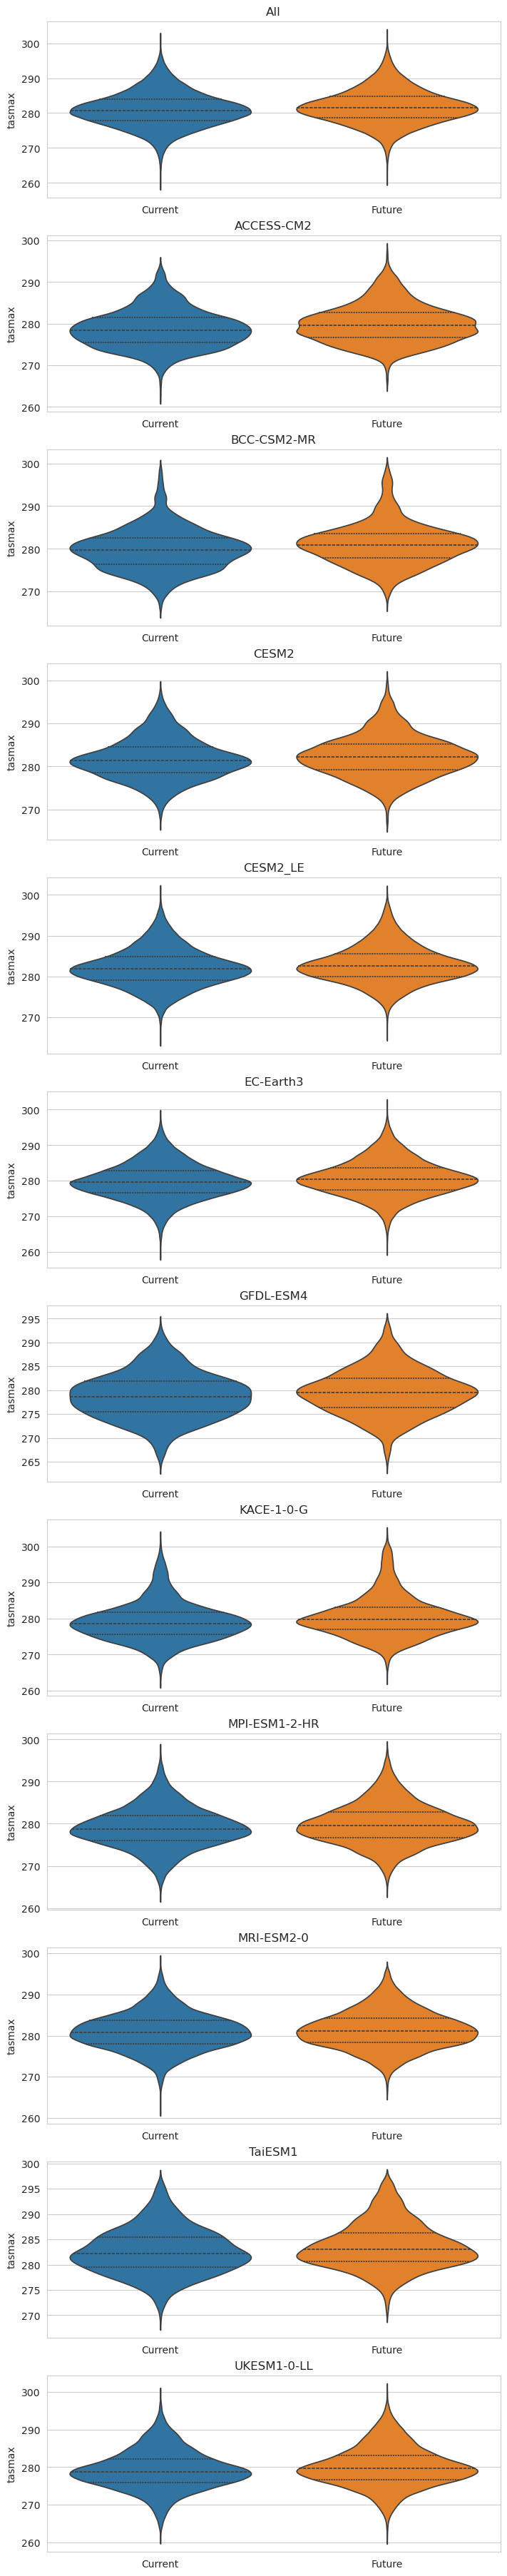

In [16]:
fig, axes = plt.subplots(
    nrows=len(all_keys),
    figsize=(7, 3 * len(all_keys)),
    constrained_layout=True
)

if len(all_keys) == 1:
    axes = [axes]

for ax, esm in zip(axes, all_keys):

    cur = esm_data_cur_dict[esm]
    fut = esm_data_fut_dict[esm]

    sns.violinplot(
        data=[cur, fut],
        ax=ax,
        inner='quartile'
    )

    ax.set_xticklabels(['Current', 'Future'])
    ax.set_title(esm)
    ax.set_ylabel(variable_name)

plt.show()

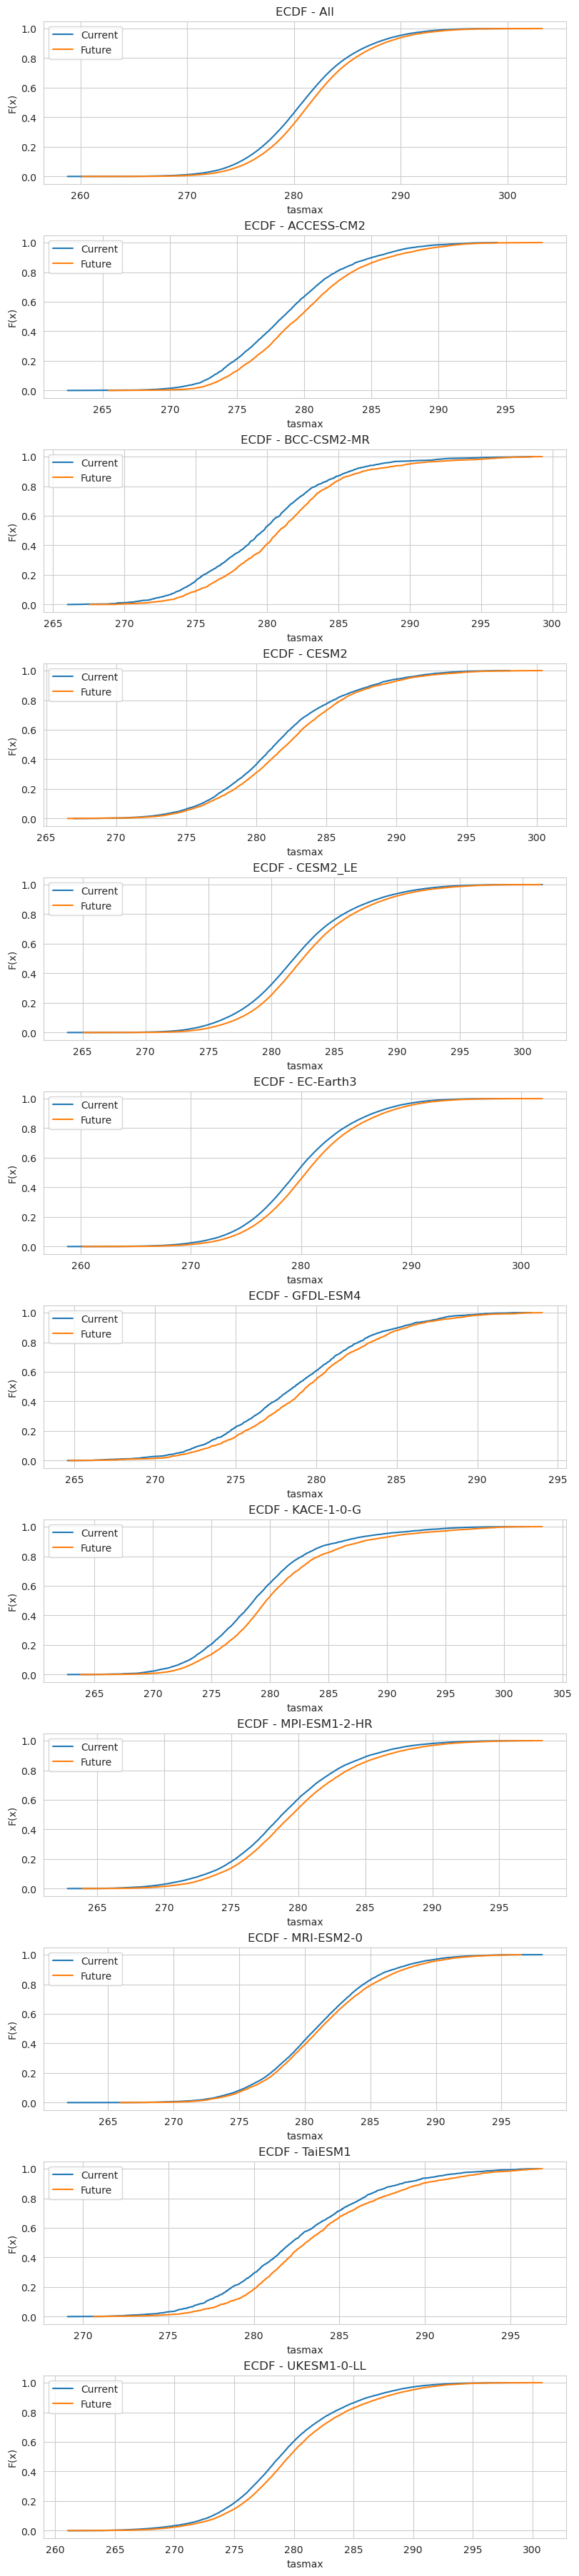

In [17]:
fig, axes = plt.subplots(
    nrows=len(all_keys),
    figsize=(8, 3 * len(all_keys)),
    constrained_layout=True
)

if len(all_keys) == 1:
    axes = [axes]

for ax, esm in zip(axes, all_keys):

    cur = np.sort(esm_data_cur_dict[esm])
    fut = np.sort(esm_data_fut_dict[esm])

    ecdf_cur = np.arange(1, len(cur)+1) / len(cur)
    ecdf_fut = np.arange(1, len(fut)+1) / len(fut)

    ax.plot(cur, ecdf_cur, label='Current')
    ax.plot(fut, ecdf_fut, label='Future')

    ax.set_title(f"ECDF - {esm}")
    ax.set_xlabel(variable_name)
    ax.set_ylabel("F(x)")
    ax.legend()

plt.show()

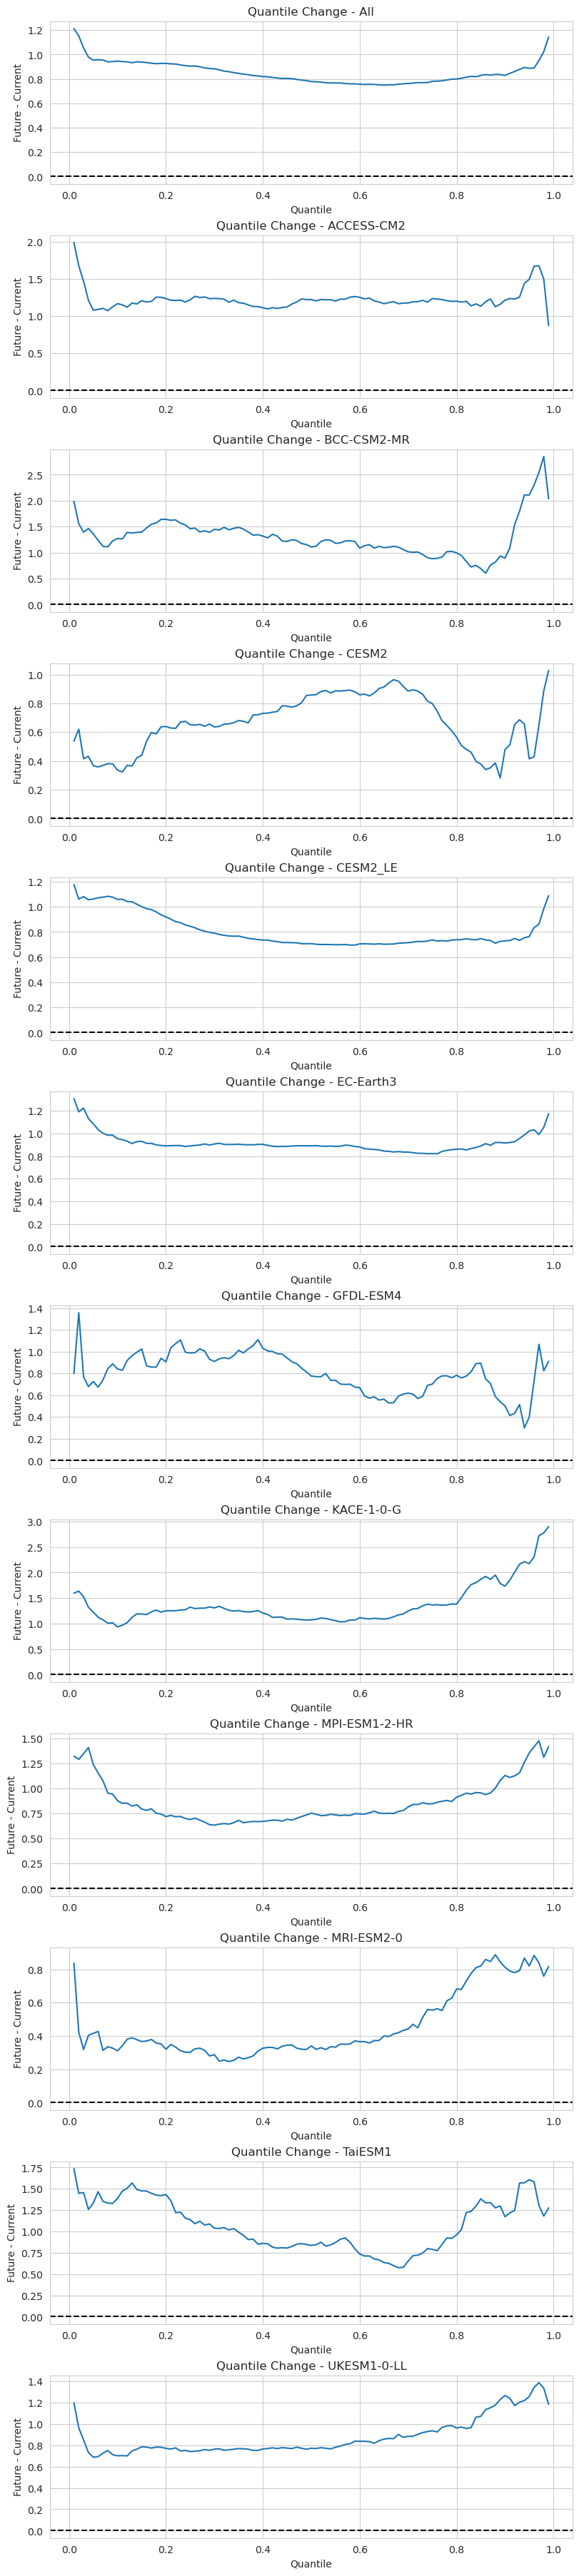

In [18]:
quantiles = np.linspace(0.01, 0.99, 99)

fig, axes = plt.subplots(
    nrows=len(all_keys),
    figsize=(8, 3 * len(all_keys)),
    constrained_layout=True
)

if len(all_keys) == 1:
    axes = [axes]

for ax, esm in zip(axes, all_keys):

    cur_q = np.quantile(esm_data_cur_dict[esm], quantiles)
    fut_q = np.quantile(esm_data_fut_dict[esm], quantiles)

    delta = fut_q - cur_q

    ax.plot(quantiles, delta)

    ax.axhline(0, color='black', linestyle='--')

    ax.set_title(f"Quantile Change - {esm}")
    ax.set_xlabel("Quantile")
    ax.set_ylabel("Future - Current")

plt.show()

In [19]:


rows = []

for esm in all_keys:

    cur = esm_data_cur_dict[esm]
    fut = esm_data_fut_dict[esm]

    ks_stat, ks_p = ks_2samp(cur, fut)

    rows.append({
        'ESM': esm,
        'Current Mean': np.mean(cur),
        'Future Mean': np.mean(fut),
        'Delta Mean': np.mean(fut) - np.mean(cur),
        'Current Std': np.std(cur),
        'Future Std': np.std(fut),
        'KS Statistic': ks_stat,
        'KS p-value': ks_p,
        'Wasserstein': wasserstein_distance(cur, fut),
    })

summary_df = pd.DataFrame(rows)

print(summary_df)

              ESM  Current Mean  Future Mean  Delta Mean  Current Std  \
0             All    280.997192   281.853973    0.856781     4.964042   
1      ACCESS-CM2    278.762146   279.991089    1.228943     4.597398   
2     BCC-CSM2-MR    279.827240   281.120422    1.293182     4.828984   
3           CESM2    281.731812   282.396393    0.664581     4.732688   
4        CESM2_LE    282.122559   282.936035    0.813477     4.644077   
5       EC-Earth3    279.851440   280.770203    0.918762     5.023650   
6       GFDL-ESM4    278.758331   279.565186    0.806854     4.749747   
7      KACE-1-0-G    279.163391   280.532959    1.369568     5.354708   
8   MPI-ESM1-2-HR    279.054688   279.919586    0.864899     4.801111   
9      MRI-ESM2-0    281.001648   281.461639    0.459991     4.448814   
10        TaiESM1    282.616791   283.691132    1.074341     4.519021   
11    UKESM1-0-LL    279.225952   280.102905    0.876953     5.168033   

    Future Std  KS Statistic     KS p-value  Wasse